In [1]:
import distrax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax


# 1. Define the Flow Architecture
def make_flow_model(params):
    """Creates the flow model using the learnable parameters.
    
    Args:
        params: Array of shape (num_bins, 3 * num_bins + 1) defining the spline.
                (widths, heights, slopes)
    """
    # Layer 1: Rational Quadratic Spline (R -> R)
    # This layer does the heavy lifting of reshaping the density.
    # range_min/max define the "active" region of the spline; outside is identity.
    spline_layer = distrax.RationalQuadraticSpline(
        params,
        range_min=-5.,
        range_max=5.,
        boundary_slopes="identity",
        min_bin_size=1e-3,
    )

    # Layer 2: Exp Bijector (R -> R+)
    # Maps the unconstrained real line to strictly positive values.
    # We define it manually as Distrax doesn't always expose a standalone 'Exp'.
    # Forward: z -> exp(z) (Latent to Data)
    # Inverse: x -> log(x) (Data to Latent)
    exp_layer = distrax.Lambda(
        forward=jnp.exp,
        inverse=jnp.log,
        forward_log_det_jacobian=lambda z: z,  # log|d/dz exp(z)| = z
        inverse_log_det_jacobian=lambda x: -jnp.log(x), # log|d/dx log(x)| = -log(x)
        event_ndims_in=0,
        event_ndims_out=0,
    )

    # Compose: Latent (z) -> Spline -> Exp -> Data (x)
    bijector = distrax.Chain([exp_layer, spline_layer])

    # Base Distribution: Standard Normal
    base_dist = distrax.Normal(loc=0., scale=1.)

    # Flow: p(x)
    flow = distrax.Transformed(base_dist, bijector)

    return flow

# 2. CDF Function (The goal of your request)
def evaluate_pdf_sf(flow, x):
    """Directly evaluates the CDF of x using the Probability Integral Transform.
    CDF_x(x) = CDF_normal(z), where z = flow.inverse(x)
    """
    # Map Data (x) -> Latent (z)
    z = flow.bijector.inverse(x)

    # Evaluate Standard Normal CDF at z
    return jax.scipy.stats.norm.pdf(z), jax.scipy.stats.norm.sf(z)

# --- Training Setup ---

# Generate some synthetic strictly positive data (e.g., Log-Normal)
key = jax.random.PRNGKey(42)
true_data = jax.random.wald(key, 1.0, (1000,)) + 0.3 # Shifted Wald

# Initialize Spline Parameters
# Shape: (1, 3 * num_bins + 1) because it's a 1D flow
num_bins = 8
# We initialize randomly unconstrained, the spline layer handles softmax/normalization internally
params = jax.random.normal(key, (1, num_bins * 3 + 1))

optimizer = optax.adam(learning_rate=0.01)
opt_state = optimizer.init(params)

# Loss Function: Negative Log Likelihood
@jax.jit
def loss_fn(params, x_batch):
    flow = make_flow_model(params)
    return -jnp.mean(flow.log_prob(x_batch))

# Update Step
@jax.jit
def update(params, opt_state, x_batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, x_batch)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss, new_params, new_opt_state

# --- Main Loop ---
print("Training...")
for i in range(2000):
    loss_val, params, opt_state = update(params, opt_state, true_data)
    if i % 200 == 0:
        print(f"Step {i}, Loss: {loss_val:.4f}")

# --- Evaluation ---
print("\nEvaluating CDF...")
final_flow = make_flow_model(params)

# Test on a specific value, e.g., x = 2.0
test_x = jax.random.wald(key, 1.0, (100,)) + 0.3
pdf_val, sf_val = evaluate_pdf_sf(final_flow, test_x)

# print(f"CDF at x=2.0: {cdf_val[0]:.4f}")
# # Verification with empirical CDF
# empirical_cdf = (true_data <= 2.0).mean()
# print(f"Empirical CDF: {empirical_cdf:.4f}")

Training...
Step 0, Loss: 2.2153
Step 200, Loss: 0.8969
Step 400, Loss: 0.8796
Step 600, Loss: 0.8769
Step 800, Loss: 0.8754
Step 1000, Loss: 0.8743
Step 1200, Loss: 0.8736
Step 1400, Loss: 0.8730
Step 1600, Loss: 0.8726
Step 1800, Loss: 0.8722

Evaluating CDF...


In [2]:
from confrdm.likelihoods.rdm import inv_gauss_logpdf
from confrdm.likelihoods.rdm import inv_gauss_logsf

ref_sf = jnp.exp(inv_gauss_logsf(test_x - 0.3, 1.0, 1.0))

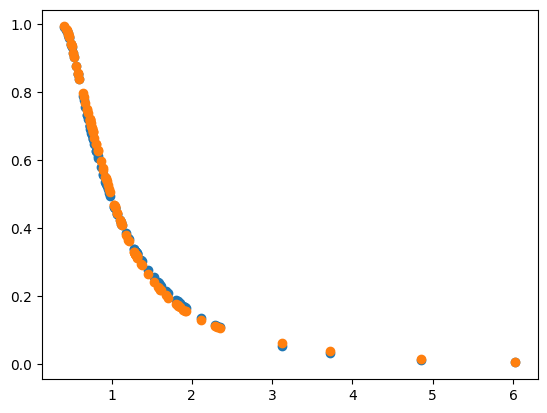

In [3]:
fig, ax = plt.subplots()

ax.scatter(test_x, ref_sf)
ax.scatter(test_x, sf_val)

In [ ]:
import haiku as hk
import jax
import jax.numpy as jnp
import numpy as np
import optax


# 1. Data Generator (Contextual)
def sample_conditional_wald(key, batch_size):
    k1, k2, k3 = jax.random.split(key, 3)

    # Randomly vary the true parameters (the context)
    mu = jax.random.uniform(k1, (1, 1), minval=0.0, maxval=2.0)
    lam = jax.random.uniform(k2, (1, 1), minval=0.2, maxval=1.0)
    context = jnp.concatenate([mu, lam], axis=-1)

    x = jax.random.wald(k3, mean=(mu**3 / lam), shape=(batch_size, 1)) / mu**2 * lam

    return x, context

# 2. Define the Conditional Flow with Haiku
def flow_fn(x, context):
    num_bins = 8

    conditioner = hk.nets.MLP([64, 64, num_bins * 3 + 1], activation=jax.nn.gelu)
    spline_params = conditioner(context)

    spline_layer = distrax.RationalQuadraticSpline(
        spline_params,
        range_min=-10.,
        range_max=10.,
        boundary_slopes="identity",
        min_bin_size=1e-3,
    )

    exp_layer = distrax.Lambda(
        forward=jnp.exp,
        inverse=jnp.log,
        forward_log_det_jacobian=lambda z: z,
        inverse_log_det_jacobian=lambda x: -jnp.log(x),
        event_ndims_in=0,
        event_ndims_out=0,
    )

    bijector = distrax.Chain([exp_layer, spline_layer])

    base_dist = distrax.Normal(loc=0., scale=1.)

    flow = distrax.Transformed(base_dist, bijector)

    return flow.log_prob(x), flow


def log_prob_fn(x, context):
    lp, _ = flow_fn(x, context)
    return lp

model = hk.without_apply_rng(hk.transform(log_prob_fn))

optimizer = optax.adam(1e-5)

@jax.jit
def update(params, opt_state, x, context):
    def loss(p):
        # maximize log_prob -> minimize -log_prob
        log_probs = model.apply(p, x, context)
        return -jnp.mean(log_probs)

    grads = jax.grad(loss)(params)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    loss_val = loss(params)
    return new_params, new_opt_state, loss_val

# Init
rng_seq = hk.PRNGSequence(42)
dummy_x = jnp.ones((1, 1))
dummy_ctx = jnp.ones((1, 2)) # 2 dims for [mu, sigma]
params = model.init(next(rng_seq), dummy_x, dummy_ctx)
opt_state = optimizer.init(params)

print("Training Conditional Flow...")
for step in range(5000):
    x_batch, ctx_batch = sample_conditional_wald(next(rng_seq), 128)
    params, opt_state, loss = update(params, opt_state, x_batch, ctx_batch)
    if step % 500 == 0:
        print(f"Step {step}, Loss: {loss:.4f}")

# 4. Evaluate Conditional CDF
def get_pdf_sf(params, x, context):
    """Evaluates CDF of x GIVEN context.
    """
    # We need to reconstruct the flow object using the trained params and specific context
    # We define a helper inside that returns the flow object instead of log_prob
    def get_flow_object(x, c):
        _, flow = flow_fn(x, c)
        return flow

    # Bind the trained parameters to this function
    forward_fn = hk.without_apply_rng(hk.transform(get_flow_object)).apply

    # Get the specific flow instance for this context
    # Note: Distrax builds the bijector dependent on the input context here
    flow = forward_fn(params, x, context)

    # Inverse: Data (x) -> Latent (z)
    z = flow.bijector.inverse(x)

    # CDF is Standard Normal CDF of z
    return flow.log_prob(x), jax.scipy.stats.norm.logsf(z)

Training Conditional Flow...


In [ ]:
ref_sf.shape

(100,)

In [ ]:
pdf_val.shape

(100,)

(0.0, 6.0)

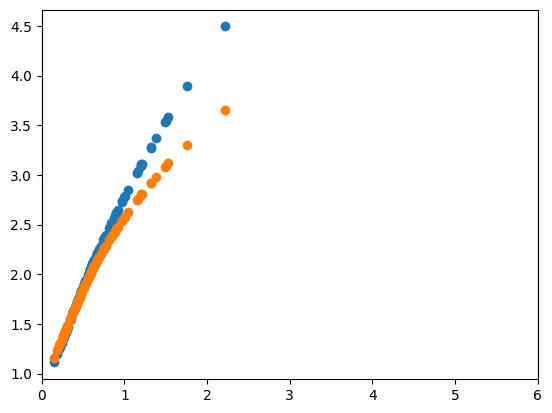

In [ ]:
test_x, theta = sample_conditional_wald(jax.random.PRNGKey(2026), 100)

pdf_val, sf_val = get_pdf_sf(params, test_x, theta)

ref_sf = inv_gauss_logsf(test_x, theta[0][0], theta[0][1])

fig, ax = plt.subplots()

ax.scatter(test_x, 1-ref_sf)
ax.scatter(test_x, 1-sf_val)

ax.set_xlim(0, 6)

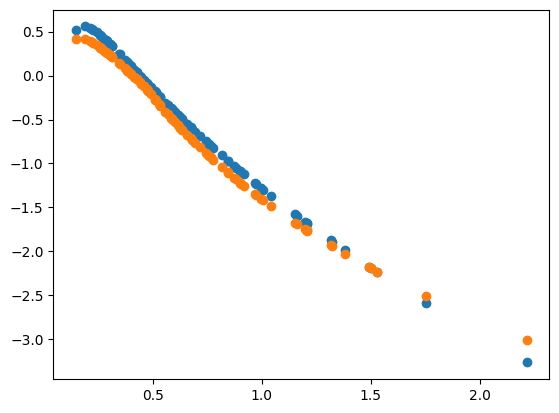

In [ ]:
ref_pdf = inv_gauss_logpdf(test_x, theta[0][0], theta[0][1])

fig, ax = plt.subplots()

ax.scatter(test_x, ref_pdf)
ax.scatter(test_x, pdf_val)

In [ ]:
@jax.jit
def inv_gauss_log_pdf_sf(rt, v, b, s, t0):
    rt = rt - t0
    rt = jnp.maximum(0.0, rt)

    # mu_winner = b/drift_winner
    mu = b/v
    # lam_winner = (b/s_winner)**2
    lam = (b/s)**2

    return get_pdf_sf(params, rt, jnp.array([[mu, lam]]))

def create_rdm_two_accumulators_likelihood(data):
    rt = data[:, 0]
    choice = data[:, 1]

    @jax.jit
    def likelihood_fun(x, min_ll=1e-12):
        x = jnp.exp(x)

        v_true = x[0] + x[1]
        v_false = x[0]
        s_true = x[2]
        s_false = 1.0
        b = x[3]
        t0 = x[4]

        log_pdf_true, log_sf_true = inv_gauss_log_pdf_sf(rt, v_true, b, s_true, t0)
        log_pdf_false, log_sf_false = inv_gauss_log_pdf_sf(rt, v_false, b, s_false, t0)

        dens_true = log_pdf_true.squeeze() + log_sf_false.squeeze()
        dens_false = log_pdf_false.squeeze() + log_sf_true.squeeze()

        ll = jnp.where(choice == 1, dens_true, dens_false)

        return jnp.where(jnp.isfinite(ll), ll, min_ll)

    return likelihood_fun

In [ ]:
from confrdm.simulators.rdm import simulate_rdm_two_accumulators

data = simulate_rdm_two_accumulators(
    v_intercept=1.0,
    v_slope=4.0,
    s_true=1.2,
    b=0.9,
    t0=0.3,
    num_obs=300,
    rng=np.random.default_rng(2026),
)["x"]

rdm_likelihood = create_rdm_two_accumulators_likelihood(data)

In [ ]:
from jax.scipy import stats


@jax.jit
def rdm_prior(x):
    def scale_logtruncnorm(x, loc, scale, a):
        return stats.truncnorm.logpdf(x, loc=loc, scale=scale, a=(a - loc) / scale, b=jnp.inf)

    x = jnp.exp(x)
    v_intercept = scale_logtruncnorm(x[0], 1.0, 0.5, 0.0)
    v_slope = scale_logtruncnorm(x[1], 4.0, 0.5, 0.0)
    s_true = scale_logtruncnorm(x[2], 1.0, 0.25, 0.0)
    b = stats.gamma.logpdf(x[3], a=12.0, scale=1.0 / 0.15)
    t0 = scale_logtruncnorm(x[4], 0.3, 0.2, 0.0)

    return v_intercept + v_slope + s_true + b + t0

In [ ]:
import blackjax


def inference_loop_multiple_chains(
    rng_key, kernel, initial_state, num_samples, num_chains,
):
    @jax.jit
    def one_step(states, rng_key):
        keys = jax.random.split(rng_key, num_chains)
        states, _ = jax.vmap(kernel)(keys, states)
        return states, states

    keys = jax.random.split(rng_key, num_samples)
    _, states = jax.lax.scan(one_step, initial_state, keys)

    return states


def warmup(sampler_fun, logdensity_fun, init_position, num_steps, rng_key, **kwargs):
    adapt = blackjax.window_adaptation(sampler_fun, logdensity_fun, **kwargs)
    (last_state, parameters), _ = adapt.run(rng_key, init_position, num_steps=num_steps)
    kernel = sampler_fun(logdensity_fun, **parameters).step
    return kernel, last_state, parameters

In [ ]:
@jax.jit
def logdensity_fun(x):
    return jnp.sum(rdm_prior(x) + rdm_likelihood(x))

In [ ]:
init_position = jnp.array([1.0, 4.0, 1.2, 0.8, 0.1])

In [ ]:
rng_key = jax.random.key(2025)

rng_key, warmup_key = jax.random.split(rng_key)

kernel, last_state, warmup_parameters = warmup(
    blackjax.nuts,
    logdensity_fun,
    jnp.log(init_position),
    2000,
    warmup_key,
    progress_bar=True,
)

Running window adaptation


In [ ]:
num_chains = 4

last_states = jax.vmap(lambda x: last_state)(np.arange(num_chains))

trace = inference_loop_multiple_chains(
    rng_key, kernel, last_states, 2000, num_chains,
)

samples = np.moveaxis(np.asarray(jnp.exp(trace.position)), (0, 1, 2), (2, 1, 0))

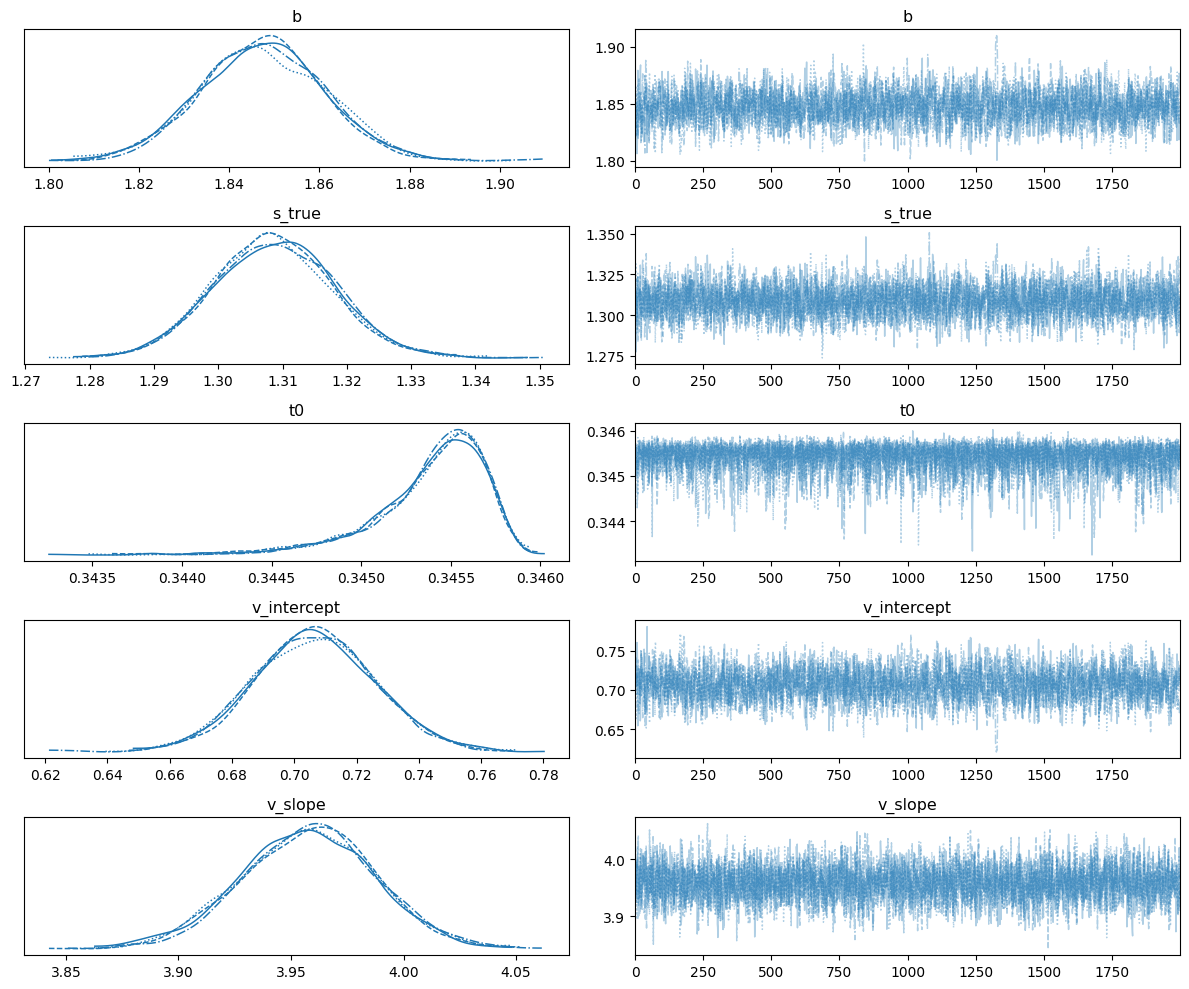

In [ ]:
import arviz as az
import matplotlib.pyplot as plt

param_names = ["v_intercept", "v_slope", "s_true", "b", "t0"]

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, samples)})
ax = az.plot_trace(idata)

plt.tight_layout()

## Conflict RDM

In [ ]:
from confrdm.simulators.rdmc import simulate_rdmc_single_accumulator

In [ ]:
jax.config.update("jax_enable_x64", True)

def sample_conditional_crdm(key, batch_size):
    k1, k2, k3, k4, k5 = jax.random.split(key, 5)

    v_c = jax.random.uniform(k1, minval=0.0, maxval=8.0)
    amp = jax.random.uniform(k2, minval=0.0, maxval=0.5)
    tau = jax.random.uniform(k3, minval=0.01, maxval=0.3)
    s = jax.random.uniform(k4, minval=0.5, maxval=1.5)
    b = jax.random.uniform(k5, minval=0.2, maxval=1.5)
    context = jnp.array([[v_c, amp, tau, s, b]])

    x = simulate_rdmc_single_accumulator(
        v_c=np.expand_dims(v_c, 0),
        amp=amp,
        tau=tau,
        s=np.expand_dims(s, 0),
        b=b,
        t0=0,
        a_shape=2.0,
        num_obs=batch_size,
        t_max=3000,
    )["x"]

    return jnp.expand_dims(x, 1), context

In [ ]:
x, context = sample_conditional_crdm(key, 100)
x.shape, context.shape

((100, 1), (1, 5))

In [ ]:
def flow_fn(x, context):
    num_bins = 8

    conditioner = hk.nets.MLP([128, 128, num_bins * 3 + 1], activation=jax.nn.gelu)
    spline_params = conditioner(context)

    spline_layer = distrax.RationalQuadraticSpline(
        spline_params,
        range_min=-3.0,
        range_max=3.0,
        boundary_slopes="identity",
        min_bin_size=1e-3,
    )

    exp_layer = distrax.Lambda(
        forward=jnp.exp,
        inverse=jnp.log,
        forward_log_det_jacobian=lambda z: z,
        inverse_log_det_jacobian=lambda x: -jnp.log(x),
        event_ndims_in=0,
        event_ndims_out=0,
    )

    bijector = distrax.Chain([exp_layer, spline_layer])

    base_dist = distrax.Normal(loc=0., scale=1.)

    flow = distrax.Transformed(base_dist, bijector)

    return flow.log_prob(x), flow

In [ ]:
jnp.log(jnp.linspace(0.1, 3.0, num=5))

Array([-2.30258509, -0.19237189,  0.43825493,  0.82198005,  1.09861229],      dtype=float64)

In [ ]:
model = hk.without_apply_rng(hk.transform(log_prob_fn))

num_steps = 5000

optimizer = optax.adam(optax.schedules.cosine_decay_schedule(5e-4, num_steps, 1e-6))

rng_seq = hk.PRNGSequence(42)
dummy_x = jnp.ones((1, 1))
dummy_ctx = jnp.ones((1, 5)) # 2 dims for [mu, sigma]
params = model.init(next(rng_seq), dummy_x, dummy_ctx)
opt_state = optimizer.init(params)

print("Training Conditional Flow...")
for step in range(num_steps):
    x_batch, ctx_batch = sample_conditional_crdm(next(rng_seq), 128)
    params, opt_state, loss = update(params, opt_state, x_batch, ctx_batch)
    if step % 500 == 0:
        print(f"Step {step}, Loss: {loss:.4f}")

Training Conditional Flow...
Step 0, Loss: 21.4477
Step 500, Loss: 32.2807
Step 1000, Loss: 11.4728
Step 1500, Loss: 20.3555
Step 2000, Loss: 32.0571
Step 2500, Loss: 19.8870
Step 3000, Loss: 17.5859
Step 3500, Loss: 20.0156
Step 4000, Loss: 31.2324
Step 4500, Loss: 32.4646


In [ ]:
@jax.jit
def crdm_log_pdf_sf(rt, v_c, amp, tau, s, b, t0):
    rt = rt - t0
    rt = jnp.maximum(0.0, rt)

    return get_pdf_sf(params, rt, jnp.array([[v_c, amp, tau, s, b]]))

def create_crdm_two_accumulators_likelihood(data):
    rt = data[:, 0]
    choice = data[:, 1]

    @jax.jit
    def likelihood_fun(x, min_ll=1e-12):
        x = jnp.exp(x)

        v_c_true = x[0] + x[1]
        v_c_false = x[0]
        amp = x[2]
        tau = x[3]
        s_true = x[4]
        s_false = 1.0
        b = x[5]
        t0 = x[6]

        log_pdf_true, log_sf_true = crdm_log_pdf_sf(rt, v_c_true, amp, tau, b, s_true, t0)
        log_pdf_false, log_sf_false = inv_gauss_log_pdf_sf(rt, v_c_false, b, s_false, t0)

        dens_true = log_pdf_true.squeeze() + log_sf_false.squeeze()
        dens_false = log_pdf_false.squeeze() + log_sf_true.squeeze()

        ll = jnp.where(choice == 1, dens_true, dens_false)

        return jnp.where(jnp.isfinite(ll), ll, min_ll)

    return likelihood_fun

In [ ]:
from confrdm.simulators.rdmc import simulate_rdmc_two_accumulators

prior_draws = {
    "v_c_intercept": 1.0,
    "v_c_slope": 5.0,
    "amp": 0.3,
    "tau": 0.05,
    "s_true": 0.9,
    "b": 1.2,
    "t0": 0.3,
}

data = simulate_rdmc_two_accumulators(
    **prior_draws,
    s_false=1.0,
    a_shape=2.0,
    num_obs=300,
    t_max=3000,
)["x"]

crdm_likelihood = create_crdm_two_accumulators_likelihood(data)

In [ ]:
@jax.jit
def crdm_prior(x):
    def scale_logtruncnorm(x, loc, scale, a):
        return stats.truncnorm.logpdf(x, loc=loc, scale=scale, a=(a - loc) / scale, b=jnp.inf)

    x = jnp.exp(x)
    v_intercept = scale_logtruncnorm(x[0], 1.0, 0.5, 0.0)
    v_slope = scale_logtruncnorm(x[1], 4.0, 0.5, 0.0)
    amp = scale_logtruncnorm(x[2], 0.3, 0.05, 0.0)
    tau = scale_logtruncnorm(x[3], 0.1, 0.05, 0.0)
    s_true = scale_logtruncnorm(x[4], 1.0, 0.25, 0.0)
    b = stats.gamma.logpdf(x[5], a=12.0, scale=0.15)
    t0 = scale_logtruncnorm(x[6], 0.3, 0.2, 0.0)

    return v_intercept + v_slope + amp + tau + s_true + b + t0

In [ ]:
@jax.jit
def logdensity_fun(x):
    return jnp.sum(crdm_prior(x) + crdm_likelihood(x))

In [ ]:
init_position = jnp.array([2.0, 2.0, 0.05, 0.05, 1.5, 0.5, 0.1])

In [ ]:
rng_key = jax.random.key(2025)

rng_key, warmup_key = jax.random.split(rng_key)

kernel, last_state, warmup_parameters = warmup(
    blackjax.nuts,
    logdensity_fun,
    jnp.log(init_position),
    2000,
    warmup_key,
    progress_bar=True,
)

Running window adaptation


In [ ]:
num_chains = 4

last_states = jax.vmap(lambda x: last_state)(np.arange(num_chains))

trace = inference_loop_multiple_chains(
    rng_key, kernel, last_states, 2000, num_chains,
)

samples = np.moveaxis(np.asarray(jnp.exp(trace.position)), (0, 1, 2), (2, 1, 0))

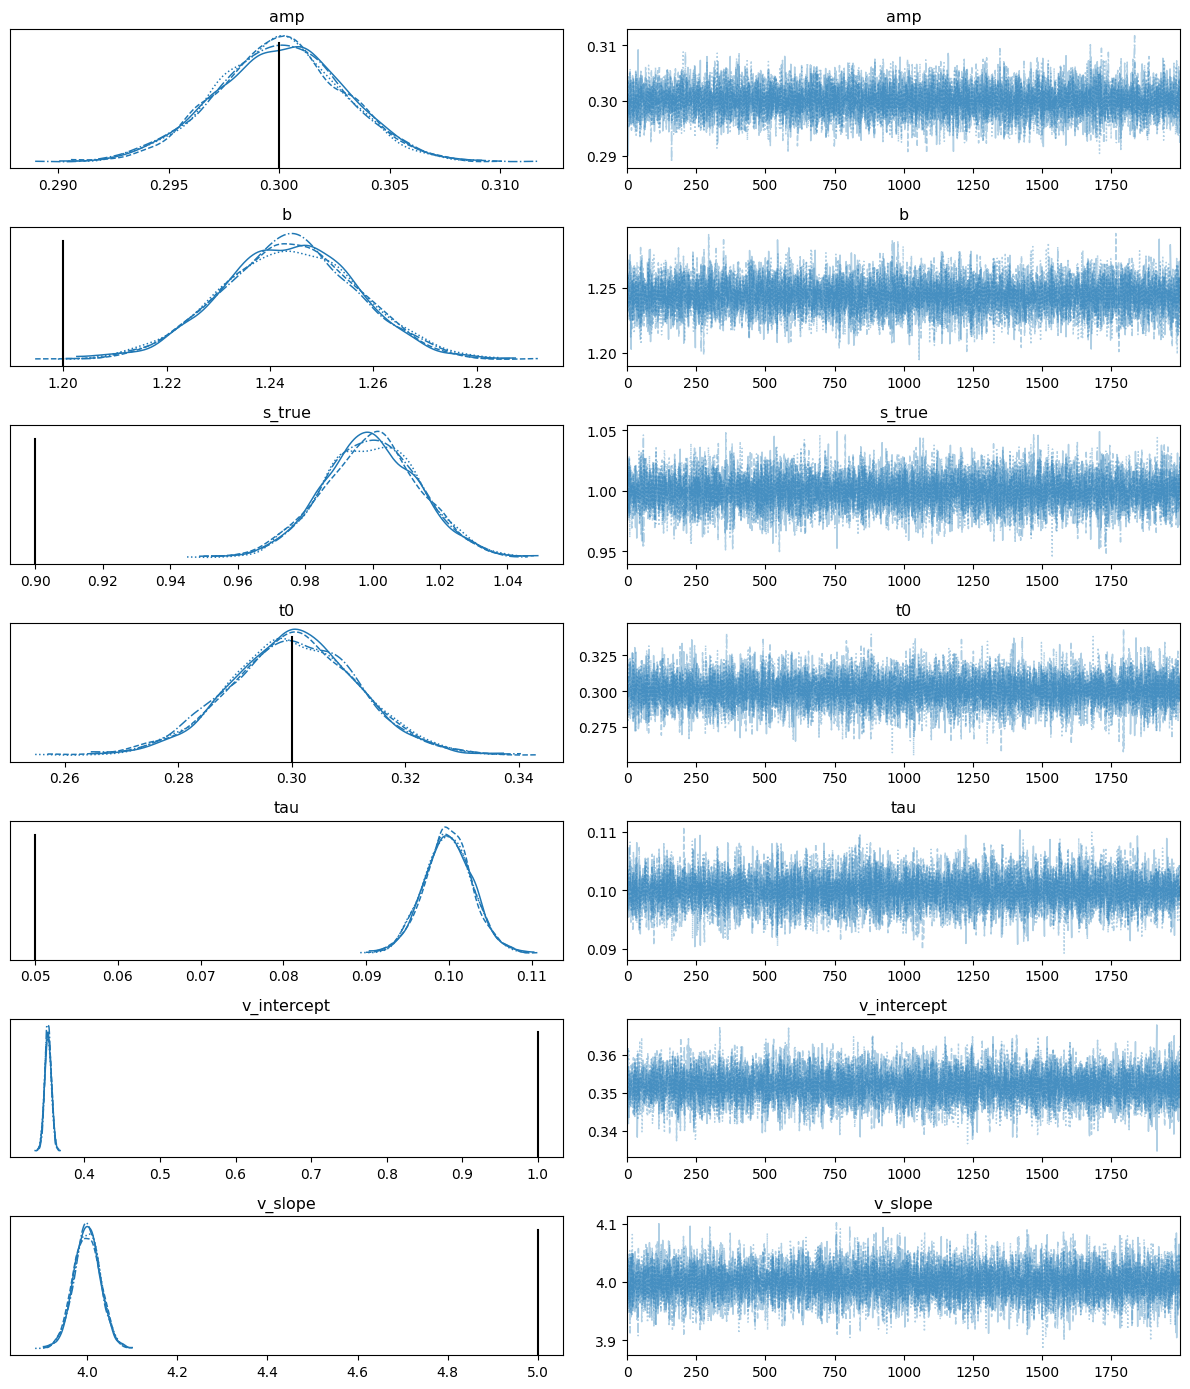

In [ ]:
param_names = ["v_intercept", "v_slope", "amp", "tau", "s_true", "b", "t0"]

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, samples)})
ax = az.plot_trace(idata)

for i, p in enumerate(sorted(prior_draws)):
    ax[i, 0].axvline(prior_draws[p], 0, 0.9, color="k")

plt.tight_layout()